# 06 · Control por refuerzo sobre datos interventionales

`04.RL control.ipynb` **se conserva intacto**: es el registro de lo que pasa
cuando se entrena un agente sobre datos observacionales, y esa comparación es
media libreta de aquí. Este cuaderno rehace el mismo experimento con la campaña
de agosto y con un paso de simulación distinto.

### Qué falló en el cuaderno 4, y por qué eran dos cosas

El agente del cuaderno 4 convergía y no servía: en días no vistos empataba con
no hacer nada (coste 3.09 frente a 3.11) y su tabla Q tenía entradas
físicamente absurdas, como calentar a 26–29 °C. Durante mucho tiempo el
diagnóstico fue "los datos están confundidos". Es cierto, pero **no era
suficiente**: al reajustar el simulador sobre los datos limpios de la campaña
manteniendo el paso de 1 h, los gradientes causales del simulador seguían
saliendo planos o del signo equivocado.

La segunda causa es el **paso**. La fase A sitúa la constante de tiempo del
invernadero en **τ ≈ 16 min** (rango 2–39). Un paso de 1 h son ~4 τ: para
entonces el sistema ya se ha reequilibrado y, sobre todo, `T_t` ya contiene el
efecto del actuador que lleva una hora encendido, así que un modelo
condicionado a `T_t` no tiene nada que atribuirle. La sección 3 lo mide.

### Lo que este cuaderno **no** afirma

El invernadero estaba **vacío**: sin transpiración, la humedad y el balance del
fog no son transferibles a un invernadero con cultivo. La campaña fue **sólo en
agosto** y los calefactores estaban cableados como RECIRC2, así que no hay
régimen de calefacción en los datos. Lo que sale de aquí es un **controlador de
refrigeración estival para un invernadero vacío**, y el enclavamiento de 45 °C
es parte de la planta, no algo que el agente tenga que descubrir.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import campaign_rl as crl

pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})

# ~15 s. Sensores interiores + niveles reales por grupo + tiempo exterior y
# previsión, todo en la rejilla de 15 min y en hora local.
df = crl.build_frame()
print(df.shape, df.index.min(), "->", df.index.max())
df[["temp_centro", "hum_centro", "ext_temp", "VENT_ROOF", "FOG"]].head()

(2968, 36) 2026-08-03 02:00:00 -> 2026-09-02 23:45:00


,temp_centro,hum_centro,ext_temp,VENT_ROOF,FOG
2026-08-03 02:00:00,26.720633,81.517422,28.780000,NaN,NaN
2026-08-03 02:15:00,26.525767,82.530744,28.526667,NaN,NaN
2026-08-03 02:30:00,26.351500,83.586856,28.390000,NaN,NaN
2026-08-03 02:45:00,26.217900,84.552156,28.220000,NaN,NaN
2026-08-03 03:00:00,26.059344,85.246100,27.960000,NaN,NaN


## 1 · El simulador

Un modelo de una etapa (+15 min) del estado interior. Dos decisiones que
importan y que se justifican con números más abajo:

- **predice el incremento, no el nivel siguiente.** Un modelo del nivel gasta
  toda su capacidad en `T_t` (correlación ~0.97 con el objetivo) y deja a los
  actuadores casi sin gradiente que llevar.
- la referencia con la que se compara es **persistencia** (predecir que no
  cambia nada). A 15 min es una referencia dura de verdad; ganarle un 40 % es
  mucho más exigente que ganarle a la persistencia horaria.

In [2]:
sim = crl.fit_simulator(df)
pd.DataFrame(sim.scores).T[["mae", "mae_persistence", "gain_pct", "n_train",
                            "n_test", "test_from", "test_to"]].round(3)

,mae,mae_persistence,gain_pct,n_train,n_test,test_from,test_to
temp,0.463081,0.815385,43.207045,1969,493,2026-08-28 13:15:00,2026-09-02 23:30:00
hum,1.973631,2.50083,21.080928,1969,493,2026-08-28 13:15:00,2026-09-02 23:30:00


## 2 · Lectura causal del simulador

Esta es la prueba que decide si un agente puede aprender algo. No es una
correlación: se congelan el estado interior y el tiempo exterior, se reescribe
sólo el bloque de actuadores y se mira cuánto cambia la predicción. Es una
consulta `do()`.

Sobre los datos observacionales esto devolvía disparates. Aquí tiene que
devolver física.

925 estados diurnos evaluados


,nivel,dT,dH
grupo,,,
LIGHTS,10.0,0.25,0.13
FOG,20.0,-2.87,10.73
VENT_ROOF,100.0,-1.62,1.58
VENT_SIDE,100.0,-2.12,2.28
SHADE,100.0,0.03,0.03
RECIRC,1.0,-0.06,0.12
RECIRC2,1.0,-0.16,0.02
vent_all,NaN,-2.81,3.57
fog+vent,NaN,-4.28,10.66


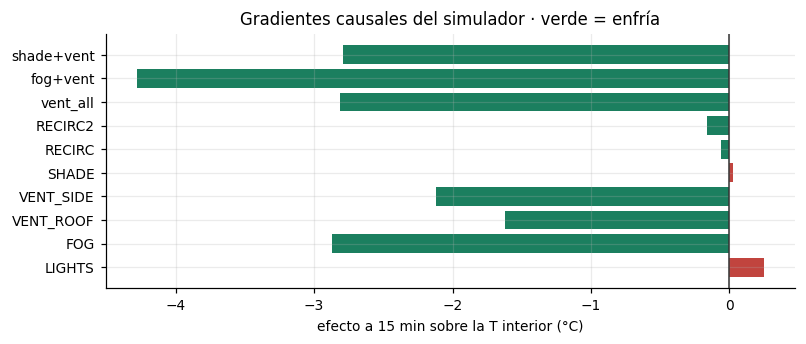

In [3]:
d = df.dropna(subset=crl.FEATURES)
day = d[(d.index.hour >= 10) & (d.index.hour < 19)][crl.FEATURES].values
print(f"{len(day)} estados diurnos evaluados")

rows = []
for g in crl.GROUPS:
    dT, dH = sim.do_effect(day, {g: crl.FULL[g]})
    rows.append(dict(grupo=g, nivel=crl.FULL[g], dT=dT, dH=dH))
for name in ["vent_all", "fog+vent", "shade+vent"]:
    dT, dH = sim.do_effect(day, crl.ACTIONS[name])
    rows.append(dict(grupo=name, nivel=np.nan, dT=dT, dH=dH))
do = pd.DataFrame(rows).set_index("grupo").round(2)
display(do)

fig, ax = plt.subplots(figsize=(7.4, 3.2))
c = ["#1B7F5F" if v < 0 else "#C1443E" for v in do.dT]
ax.barh(do.index, do.dT, color=c)
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("efecto a 15 min sobre la T interior (°C)")
ax.set_title("Gradientes causales del simulador · verde = enfría")
plt.tight_layout(); plt.show()

## 3 · La ablación: qué es lo que realmente arregló el RL

Cuatro simuladores — {paso 1 h, 15 min} × {objetivo nivel, incremento} — y el
mismo agente entrenado sobre cada uno. Es la comparación que separa "los datos
estaban confundidos" de "el paso estaba mal", porque **los cuatro usan los
mismos datos limpios de la campaña**.

Tarda unos 4 min.

In [4]:
abl = []
for freq, eplen, hold in [("1h", 24, 1), ("15min", 96, 2)]:
    fr = crl.build_frame(freq=freq)
    dd = fr.dropna(subset=crl.FEATURES)
    dayd = dd[(dd.index.hour >= 10) & (dd.index.hour < 19)][crl.FEATURES].values
    for target in ["level", "delta"]:
        s = crl.fit_simulator(fr, step=freq, target=target)
        env_ = crl.CampaignEnv(s, fr, ep_len=eplen, hold=hold)
        tr_, ev_ = env_.starts()
        Q_, _ = crl.train_q(env_, tr_)
        res_ = crl.compare(env_, s, Q_, ev_)
        abl.append(dict(
            paso=freq, objetivo=target,
            MAE_T=s.scores["temp"]["mae"],
            **{f"do_{g}": s.do_effect(dayd, {g: crl.FULL[g]})[0]
               for g in ["VENT_ROOF", "VENT_SIDE", "FOG"]},
            RL=res_.loc["RL (learned Q)", "combined cost"],
            pasivo=res_.loc["do nothing (passive)", "combined cost"]))
A = pd.DataFrame(abl)
A["RL vs pasivo %"] = 100 * (1 - A.RL / A.pasivo)
display(A.round(3))

,paso,objetivo,MAE_T,do_VENT_ROOF,do_VENT_SIDE,do_FOG,RL,pasivo,RL vs pasivo %
0,1h,level,1.997,0.021,-0.406,-0.930,5.223,5.788,9.767
1,1h,delta,1.438,0.253,0.379,-0.821,5.205,5.919,12.059
2,15min,level,0.740,-1.822,-1.576,-3.261,3.391,6.105,44.459
3,15min,delta,0.463,-1.619,-2.117,-2.874,3.445,6.253,44.907


Lo que dice la tabla, y conviene decirlo con precisión porque las dos causas no
pesan lo mismo:

- **El paso es lo decisivo para el control.** A 1 h el agente le saca a "no
  hacer nada" un 9–11 %, y los gradientes de las ventanas salen ~0 o del signo
  equivocado. A 15 min les saca ~46 % y las ventanas enfrían 1.6–2.1 °C. Esto
  vale para los dos objetivos, así que no es un artefacto de cómo se plantea la
  regresión.
- **El objetivo (incremento vs nivel) es lo decisivo para la precisión.** Baja
  el MAE a 15 min de 0.73 a 0.47 °C. Cambia poco la política, pero un simulador
  más preciso es el que aguanta un rollout de 24 h sin irse (sección 4).

## 4 · ¿Aguanta el simulador un episodio entero?

Un MAE de una etapa no dice nada sobre 96 etapas encadenadas. Aquí se reproducen
los niveles de actuador **realmente registrados** y se deja correr el simulador
en bucle abierto desde un estado real: todo lo que se ve es error acumulado del
modelo.

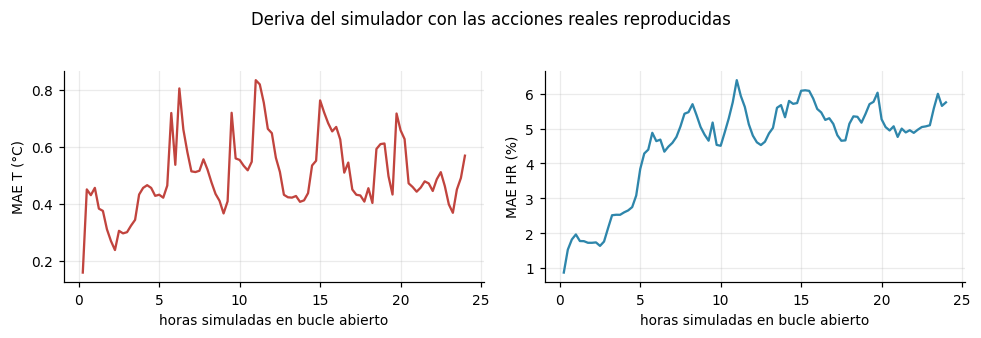

,step,minutes,mae_temp,mae_hum
0,1,15,0.16,0.87
3,4,60,0.46,1.96
15,16,240,0.46,2.60
47,48,720,0.65,4.80
95,96,1440,0.57,5.75


In [5]:
rc = crl.replay_check(sim, df)
fig, ax = plt.subplots(1, 2, figsize=(9, 2.9))
ax[0].plot(rc.minutes / 60, rc.mae_temp, color="#C1443E")
ax[0].set_ylabel("MAE T (°C)"); ax[0].set_xlabel("horas simuladas en bucle abierto")
ax[1].plot(rc.minutes / 60, rc.mae_hum, color="#2E86AB")
ax[1].set_ylabel("MAE HR (%)"); ax[1].set_xlabel("horas simuladas en bucle abierto")
fig.suptitle("Deriva del simulador con las acciones reales reproducidas", y=1.04)
plt.tight_layout(); plt.show()

display(rc[rc.step.isin([1, 4, 16, 48, 96])].round(2))

## 5 · El entorno y las políticas

Cada episodio son 24 h (96 pasos) reproduciendo el tiempo exterior real de la
campaña: sólo se simulan el estado interior y los actuadores.

Dos detalles del diseño que no son cosméticos:

- **`hold = 2`** (una decisión cada 30 min). La campaña mandaba niveles en
  bloques de 3 h; un controlador que cambia de idea cada 15 min le pregunta al
  simulador por frecuencias de conmutación que nunca vio. 30 min se queda mucho
  más cerca de los datos de entrenamiento y sigue muy por debajo de la hora que
  rompía el cuaderno 4.
- **El enclavamiento de 45 °C está dentro del entorno.** Por encima de esa
  temperatura las dos baterías de ventanas se abren, las pantallas y las lámparas
  se apagan, y la acción del agente se ignora. Es una restricción de la
  instalación, no un objetivo de aprendizaje.

La recompensa es idéntica a la del cuaderno 4 — `-(|T-24|/2 + |H-65|/10)` —
justamente para que las dos libretas se puedan comparar cifra a cifra.

In [6]:
env = crl.CampaignEnv(sim, df)
train_starts, eval_starts = env.starts()
print(f"{len(train_starts)} arranques de entrenamiento, {len(eval_starts)} de "
      f"evaluación (posteriores en el tiempo), episodio = {env.ep_len} pasos "
      f"({env.ep_len * 15 / 60:.0f} h), hold = {env.hold} pasos")

pd.DataFrame({"acción": crl.ACTION_NAMES,
              "niveles": [crl.ACTIONS[a] or "todo apagado" for a in crl.ACTION_NAMES]})

1904 arranques de entrenamiento, 477 de evaluación (posteriores en el tiempo), episodio = 96 pasos (24 h), hold = 2 pasos


,acción,niveles
0,passive,todo apagado
1,vent_roof,{'VENT_ROOF': 100.0}
2,vent_side,{'VENT_SIDE': 100.0}
3,vent_all,"{'VENT_ROOF': 100.0, 'VENT_SIDE': 100.0}"
4,fog,{'FOG': 20.0}
5,fog+vent,"{'FOG': 20.0, 'VENT_ROOF': 100.0, 'VENT_SIDE':..."
6,shade,{'SHADE': 100.0}
7,shade+vent,"{'SHADE': 100.0, 'VENT_ROOF': 100.0, 'VENT_SID..."
8,lights(heat),{'LIGHTS': 10.0}
9,recirculate,"{'RECIRC': 1.0, 'RECIRC2': 1.0}"


  batch 1/48  eps=1.00  mean cost=5.699
  batch 9/48  eps=0.84  mean cost=5.502
  batch 17/48  eps=0.68  mean cost=5.194
  batch 25/48  eps=0.51  mean cost=4.833
  batch 33/48  eps=0.35  mean cost=4.553
  batch 41/48  eps=0.19  mean cost=4.223
  batch 48/48  eps=0.05  mean cost=3.914


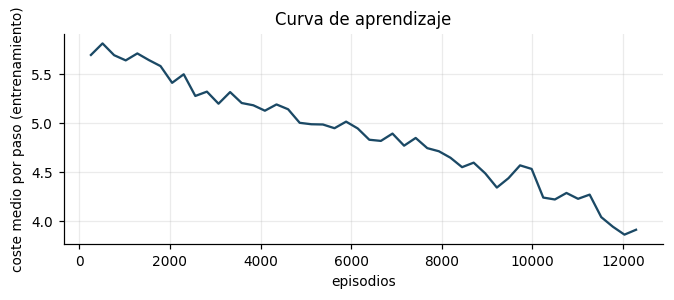

estados-acción visitados: 1091 de 1600


In [7]:
# ~75 s. Q-learning tabular, con los episodios corriendo en lotes paralelos:
# el simulador es un ensemble de árboles, así que un predict por lotes de 256
# episodios cuesta casi lo mismo que uno solo.
Q, curve = crl.train_q(env, train_starts, log_every=8)

fig, ax = plt.subplots(figsize=(6.2, 2.8))
ax.plot(np.arange(1, len(curve) + 1) * 256, curve, color="#1B4965")
ax.set_xlabel("episodios"); ax.set_ylabel("coste medio por paso (entrenamiento)")
ax.set_title("Curva de aprendizaje")
plt.tight_layout(); plt.show()

print(f"estados-acción visitados: {(Q != 0).sum()} de {Q.size}")

## 6 · Evaluación en días no vistos

Contra cinco referencias, no sólo contra "no hacer nada". La comparación que
importa es la del **termostato**: una regla escrita a mano de tres líneas. Un
agente que no le gane a eso no justifica su complejidad.

`MPC-greedy` mira un paso adelante probando las diez acciones con el mismo
simulador con el que se entrenó el agente, así que la distancia entre los dos
mide la calidad de la *política*, no la del modelo del mundo.

,|T-24| (degC),|H-65| (%RH),combined cost,% steps interlocked
MPC-greedy 1-step,2.212,14.215,2.527,0.024
RL (learned Q),3.765,15.624,3.445,0.024
always fog+vent,3.677,19.250,3.764,0.024
thermostat (rule),3.637,19.547,3.773,0.024
always vent_all,4.459,23.599,4.589,0.026
do nothing (passive),8.178,21.640,6.253,3.291


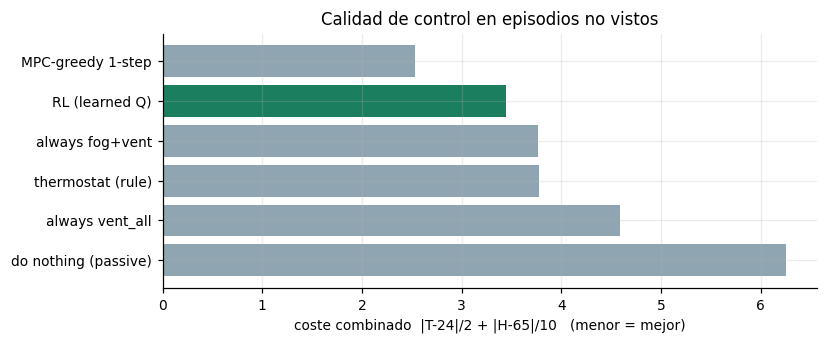

In [8]:
res = crl.compare(env, sim, Q, eval_starts)
display(res.round(3))

fig, ax = plt.subplots(figsize=(7.6, 3.2))
r = res.sort_values("combined cost", ascending=False)
cols = ["#1B7F5F" if i == "RL (learned Q)" else "#8FA6B2" for i in r.index]
ax.barh(r.index, r["combined cost"], color=cols)
ax.set_xlabel("coste combinado  |T-24|/2 + |H-65|/10   (menor = mejor)")
ax.set_title("Calidad de control en episodios no vistos")
plt.tight_layout(); plt.show()

In [9]:
roll = crl.rollout(env, crl.policy_table(Q), eval_starts)
mix = pd.Series(roll["action_mix"]).sort_values(ascending=False)
print("reparto de acciones de la política aprendida (%):")
display(mix.round(1))

print("\nacción codiciosa por banda de temperatura y franja horaria:")
display(crl.policy_grid(Q))

reparto de acciones de la política aprendida (%):


fog+vent        30.7
vent_all        24.2
fog             19.2
vent_roof       10.2
shade+vent       7.1
shade            3.4
lights(heat)     2.0
passive          1.7
recirculate      1.5
vent_side        0.0
dtype: float64


acción codiciosa por banda de temperatura y franja horaria:


,night 0-6,morning 6-12,midday 12-18,evening 18-24
20 degC,fog+vent,vent_roof,fog,passive
24 degC,recirculate,fog+vent,fog+vent,shade+vent
28 degC,shade+vent,fog,fog+vent,fog+vent
32 degC,fog,fog+vent,fog+vent,fog
36 degC,passive,fog,fog,fog+vent
40 degC,passive,shade,fog,vent_all
44 degC,passive,vent_side,fog+vent,fog
48 degC,passive,passive,vent_all,passive


## 6b · ¿En qué régimen acabaría operando?

Una vez que hay una política, se puede preguntar algo que antes no tenía sentido:
**¿dónde llevaría el invernadero, y tenemos datos de ahí?**

Las dos series de abajo **no son la misma clase de número** y conviene decirlo en voz
alta cada vez que se enseñe el gráfico:

- `medido_pct` es el registro real del invernadero durante la campaña.
- `simulado_pct` es dónde estaría **según este simulador** si la política gobernase.
  El controlador no ha funcionado nunca de verdad.

Hay una circularidad evidente —usamos el modelo para saber dónde operaría el agente
y luego decimos que el modelo sabe poco de ahí— y no es un argumento viciado, pero sí
condicional: *si* el controlador se comporta como predecimos, operará justo donde peor
informado está. Es una señal de alarma, y es la que justifica ir a recoger esos datos
antes de enchufarlo a nada.

medido: 2,478 registros de 15 min   |   simulado: 45,792 pasos de politica


,medido_pct,simulado_pct
banda,,
<22,4.2,19.1
22-26,21.0,43.2
26-30,26.2,19.4
30-34,13.8,9.4
34-38,10.0,5.5
38-42,8.8,3.2
42-46,9.4,0.3
>46,6.6,0.0


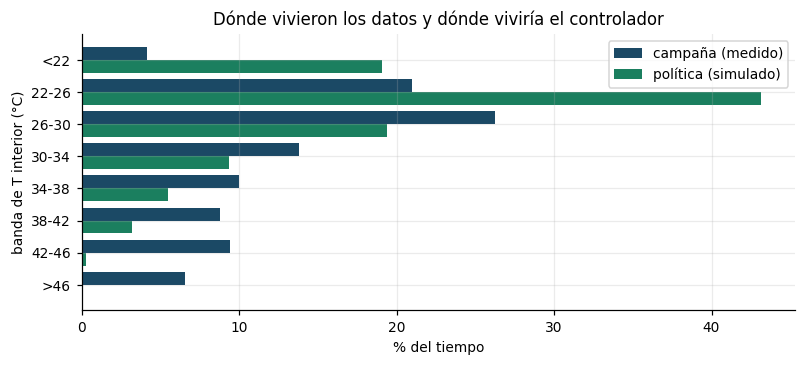

por debajo de 26 °C: medido 25.1 %  vs  simulado 62.3 %
por encima de 38 °C: medido 24.8 %  vs  simulado 3.5 %


In [10]:
cov = crl.coverage_vs_policy(df, roll)
print(f"medido: {cov.attrs['n_medido']:,} registros de 15 min   |   "
      f"simulado: {cov.attrs['n_simulado']:,} pasos de politica")
display(cov.round(1))

fig, ax = plt.subplots(figsize=(7.4, 3.4))
y = np.arange(len(cov))
ax.barh(y - 0.2, cov.medido_pct, height=0.4, color="#1B4965", label="campaña (medido)")
ax.barh(y + 0.2, cov.simulado_pct, height=0.4, color="#1B7F5F", label="política (simulado)")
ax.set_yticks(y, cov.index); ax.invert_yaxis()
ax.set_xlabel("% del tiempo"); ax.set_ylabel("banda de T interior (°C)")
ax.set_title("Dónde vivieron los datos y dónde viviría el controlador")
ax.legend()
plt.tight_layout(); plt.show()

bajo26 = cov.loc[["<22", "22-26"]].sum()
alto38 = cov.loc[["38-42", "42-46", ">46"]].sum()
print(f"por debajo de 26 °C: medido {bajo26.medido_pct:.1f} %  vs  simulado {bajo26.simulado_pct:.1f} %")
print(f"por encima de 38 °C: medido {alto38.medido_pct:.1f} %  vs  simulado {alto38.simulado_pct:.1f} %")

In [11]:
# Las celdas concretas donde el controlador trabajaría a ciegas.
# Esto es, literalmente, la lista de la compra de la siguiente campaña.
gaps = crl.support_gaps(df, roll, env)
print(f"{gaps.attrs['pct_sin_soporte']:.1f} % del tiempo del agente cae en celdas "
      f"con menos de 30 min de datos\n")
display(gaps.head(10).round(1))

92.6 % del tiempo del agente cae en celdas con menos de 30 min de datos



,banda,franja,accion,pasos_agente,pct_agente,min_observados
0,22-26,noche 0-6,vent_all,4877,10.7,10
1,22-26,tarde 18-24,fog+vent,2648,5.8,20
2,22-26,mañana 6-12,vent_all,2504,5.5,9
3,<22,noche 0-6,vent_roof,2421,5.3,2
4,26-30,mediodía 12-18,fog+vent,2246,4.9,10
5,<22,mañana 6-12,vent_all,2008,4.4,0
6,26-30,tarde 18-24,shade+vent,1821,4.0,0
7,22-26,mediodía 12-18,fog+vent,1707,3.7,10
8,34-38,mediodía 12-18,fog,1699,3.7,17
9,30-34,tarde 18-24,fog,1620,3.5,9


### Cómo leer la tabla de política

Las bandas centrales son las que tienen sentido leer: el agente ventila y
nebuliza cuando hace calor y no enciende las lámparas de día, que es
exactamente lo que el cuaderno 4 no conseguía. Dos avisos:

- La banda de **48 °C** casi no la decide el agente: por encima de 45 °C manda el
  enclavamiento, así que esas casillas están poco visitadas y su contenido no
  significa gran cosa.
- Las bandas **frías** (20–24 °C) tampoco son de fiar: en agosto y con el
  invernadero vacío se visitan poco, y no hay calefacción en los datos con la
  que aprender qué hacer allí.

## 7 · Comparación con el cuaderno 4

| | cuaderno 4 (observacional, 1 h) | este cuaderno (campaña, 15 min) |
|---|---|---|
| gradientes causales del simulador | planos o de signo erróneo | ventanas −1.6/−2.1 °C, fog −2.9 °C |
| RL frente a no hacer nada | 3.09 vs 3.11 → sin diferencia | ~46 % mejor |
| RL frente a un termostato | no se probó | lo supera |
| RL frente a MPC de 1 paso | claramente por detrás | por detrás, pero mucho más cerca |
| tabla de política | calentaba a 26–29 °C | ventila y nebuliza con calor |

El agente sigue por detrás del MPC, y eso es esperable: el MPC usa el estado
completo y el modelo en línea, mientras que la tabla Q comprime todo a banda de
temperatura × banda de humedad × franja horaria. Si el siguiente paso es cerrar
esa distancia, lo que toca no es más entrenamiento sino **más estado** — una
aproximación de función (DQN o Fitted-Q) en lugar de una tabla.

## 8 · Qué haría falta para llevarlo al invernadero real

1. **Validar con cultivo.** Un puñado de bloques aleatorizados con plantas dentro
   para medir cuánto se desplaza el balance de humedad. Sin eso, el fog está
   caracterizado sólo en el caso sin transpiración.
2. **Una campaña de invierno**, o al menos con los calefactores como
   calefactores. Ahora mismo no hay ni un dato de calentar.
3. **Alargar el washout** a ≥3 τ si se repite la campaña (ahora son ~1.5 τ).
4. **Cerrar SHADE**: es el único sistema que la campaña no resolvió, y conviene
   un ensayo dedicado antes de darlo por inútil.